# Cost saving opportunity for HCP

This jupyter notebook uses the following HCE table to get CPU utilization and AWS cost dataset:
* uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
* uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view

Please read [this decision record](https://salesforce.quip.com/9u7CATaZNDz8) to understand how to calculate the utilization and cost.


If P95 CPU Utilization < 35%:

$$
  Saving Opportunity = \left(HCE Pod Cost ($) * 0.5\right) \times \left( 1-\frac{P95 CPU Utilization}{35} \right)
$$



## Initialization

In [35]:
%reload_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../'))
sys.path.insert(0, module_path)

from huron.pod import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
from datetime import datetime, timedelta
from collections import Counter

# If you want to print out SQL Query, set log level to logging.INFO.
logging.getLogger().setLevel(logging.INFO)

## Connect to UIP

### Option 1: UIP Notebook (Recommended)

Create Notebook by following [User Guide - UIP Notebook 2.0](https://confluence.internal.salesforce.com/display/UIP/User+Guide+-+UIP+Notebook+2.0#UserGuideUIPNotebook2.0-Prerequisites).

### Option 2: Local environment

1. Download [cacert.pem](https://git.soma.salesforce.com/Infrastructure-Security/puppet_pki_agent/blob/master/files/prod_ca/cacerts.pem) and save it as `.cacert.pem`
2. Copy the trino access code from [Salesforce trino authenticator](https://bdmpresto-access-server.sfproxy.uip.aws-esvc1-useast2.aws.sfdc.cl/)
3. Update the [.secrets.json](./.secrets.json) file

```json
{
    "username": "your_user_name",
    "access_code": "trino_access_code"
}
```

In [36]:
conn = None

try:
    from huron import connect_huron
    conn = connect_huron()
except:
    from uip_client.trino import TrinoConnection

    conn = TrinoConnection(
        catalog='huron-metrics',
        schema='metrics_hourly'
    )

INFO:root:Using Certificate Authentication...


## 2. Configure environment

By default, this script queries the metrics for `stage`, `esvc`, and `prod` environments. If you want to change the environment, please edit `ENV_TYPE` below.

In [37]:
ENV_TYPE = ['dev', 'test', 'perf','prod', 'stage', 'esvc']

TIMERANGE_FROM = '2025-08-01 00:00:00'
TIMERANGE_TO = '2025-08-31 00:00:00'

# Configure maximum rows for displaying dataframes
pd.options.display.max_rows = 100
# Configure maximum cols for displaying dataframes
pd.options.display.max_columns = 50
pd.options.display.float_format = '{:.3f}'.format

NAMESPACES = ["sam-system", "kube-system"]

# Set default custom filter. filter only sam cluster.
CUSTOM_FILTERS = "k8s_cluster like 'sam-%'"
# e.g. filter out coredns pod
#CUSTOM_FILTERS = "k8s_cluster like 'sam-%' AND k8s_pod_name like 'coredns%'"

In [38]:
# The following template gets the maximum request cpu and memory from kube-stat-metric
SQL_RESOURCE_TEMPLATE = """
with dedupe as (
  SELECT
      _time,
      scope,
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
      k8s_container_name,
      element_at(tags,'resource') AS metric_type,
      MAX(max_value) AS value
  FROM huron_iceberg.metrics.metrics_hourly
  WHERE
    scope like '%(scope)s'
    AND metric = 'kube_pod_container_resource_requests'
    AND element_at(tags, 'resource') IN ('cpu', 'memory')
    AND element_at(tags, 'environment_type') in (%(envs)s)
    AND _time between TIMESTAMP '%(timerange_from)s' and TIMESTAMP '%(timerange_to)s'
    %(filters)s
  GROUP BY
      1,2,3,4,5,6,7
), sum_agg as (
  SELECT
      _time,
      scope, 
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
    SUM(CASE
         WHEN metric_type = 'cpu'
         THEN value
         ELSE NULL
    END) as pod_request_cpu,
    SUM(CASE
         WHEN metric_type = 'memory'
         THEN value
         ELSE NULL
    END) as pod_request_mem
    FROM dedupe
  GROUP BY 1,2,3,4,5
)
SELECT
  format_datetime(_time, 'yyyyMMdd') as date_key,
  scope, 
  k8s_cluster,
  k8s_namespace,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  MAX(ROUND(pod_request_cpu, 5)) as request_cpu,
  MAX(pod_request_mem) as request_memory
FROM sum_agg
GROUP BY 1,2,3,4,5
ORDER BY date_key, scope, k8s_cluster, k8s_pod_name asc

"""

df_resource_spec = get_pod_with_resource_quota(conn, SQL_RESOURCE_TEMPLATE, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, HOURLY_METRIC_TABLE, NAMESPACES, CUSTOM_FILTERS)
df_resource_spec['resource_type'] = df_resource_spec.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_resource_spec['resource_name'] = df_resource_spec.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_resource_spec['deployment_name'] = df_resource_spec.apply(extract_deployment, axis=1)
df_resource_spec

INFO:root:
with dedupe as (
  SELECT
      _time,
      scope,
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
      k8s_container_name,
      element_at(tags,'resource') AS metric_type,
      MAX(max_value) AS value
  FROM huron_iceberg.metrics.metrics_hourly
  WHERE
    scope like 'kube-state-metrics.aws.%'
    AND metric = 'kube_pod_container_resource_requests'
    AND element_at(tags, 'resource') IN ('cpu', 'memory')
    AND element_at(tags, 'environment_type') in ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND _time between TIMESTAMP '2025-08-01 00:00:00' and TIMESTAMP '2025-08-31 00:00:00'
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
  GROUP BY
      1,2,3,4,5,6,7
), sum_agg as (
  SELECT
      _time,
      scope, 
      k8s_cluster,
      k8s_namespace,
      k8s_pod_name,
    SUM(CASE
         WHEN metric_type = 'cpu'
         THEN value
         ELSE NULL
    END) as pod_request_cpu,
    SUM(CASE
         WHEN metric_

,date_key,scope,k8s_cluster,k8s_namespace,pod_group,k8s_pod_name,request_cpu,request_memory,resource_type,resource_name,deployment_name
0,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-load-balancer-controller-59654bb7b8,aws-load-balancer-controller-59654bb7b8-qfk42,0.063,1038683533.000,replicaset,aws-load-balancer-controller-59654bb7b8,aws-load-balancer-controller
1,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-node,aws-node-lxm2h,0.025,67108864.000,daemonset,aws-node,aws-node
2,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,sam-system,cloudwatch-logexport-598816239137,cloudwatch-logexport-598816239137-1,0.220,786432000.000,statefulset,cloudwatch-logexport,cloudwatch-logexport
3,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,coredns-fc859958b,coredns-fc859958b-pjdmb,0.100,2147483648.000,replicaset,coredns-fc859958b,coredns
4,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,sam-system,dataplane-test-ds,dataplane-test-ds-c5tzj,0.080,492830720.000,daemonset,dataplane-test-ds,dataplane-test-ds
...,...,...,...,...,...,...,...,...,...,...,...
932955,20250831,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,snapshot-controller-74bc6875d9,snapshot-controller-74bc6875d9-bvhzq,0.011,23574998.000,replicaset,snapshot-controller-74bc6875d9,snapshot-controller
932956,20250831,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,snapshot-validation-58d4fbf49c,snapshot-validation-58d4fbf49c-f99h9,0.200,536870912.000,replicaset,snapshot-validation-58d4fbf49c,snapshot-validation
932957,20250831,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,vertical-pod-autoscaler-admission-controller-5...,vertical-pod-autoscaler-admission-controller-5...,0.250,268435456.000,replicaset,vertical-pod-autoscaler-admission-controller-5...,vertical-pod-autoscaler-admission-controller
932958,20250831,aws.test1-uswest2.unified-engagement,sam-restricted1,kube-system,vertical-pod-autoscaler-recommender-6cc6649dd8,vertical-pod-autoscaler-recommender-6cc6649dd8...,0.011,144645763.000,replicaset,vertical-pod-autoscaler-recommender-6cc6649dd8,vertical-pod-autoscaler-recommender


In [39]:
# grouping by cluster
df_resource_quota_per_deploy = df_resource_spec[['date_key','scope','k8s_cluster','k8s_namespace','deployment_name', 'request_cpu', 'request_memory']].groupby(by=['date_key','scope','k8s_cluster','k8s_namespace','deployment_name', 'request_cpu', 'request_memory']).any().reset_index()
df_resource_quota_per_deploy['date_key'] = pd.to_numeric(df_resource_quota_per_deploy['date_key'])
df_resource_quota_per_deploy

,date_key,scope,k8s_cluster,k8s_namespace,deployment_name,request_cpu,request_memory
0,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-load-balancer-controller,0.063,1038683533.000
1,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,aws-node,0.025,67108864.000
2,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,coredns,0.100,2147483648.000
3,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,ebs-csi-controller,0.077,217673496.000
4,20250801,aws.aws-dev2-uswest2.apiq,sam-processing1,kube-system,ebs-csi-node,0.300,805306368.000
...,...,...,...,...,...,...,...
889392,20250831,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,komputegroup,0.200,268435456.000
889393,20250831,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,kube-hpa-generator,0.570,1474297856.000
889394,20250831,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,orphaned-volumes-pruner,0.200,524288000.000
889395,20250831,aws.test1-uswest2.unified-engagement,sam-restricted1,sam-system,orphaned-volumes-pruner,0.250,792723456.000


In [40]:
# Calculate 
sql_cpu_util = """
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND level = 'pod'
    AND metric_name = 'cpu_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_cpu,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_cpu
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc
"""

df_hce_cpu_util = query_aws_pod_unit_cost(conn, sql_cpu_util, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
df_hce_cpu_util['resource_type'] = df_hce_cpu_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_hce_cpu_util['resource_name'] = df_hce_cpu_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_hce_cpu_util['deployment_name'] = df_hce_cpu_util.apply(extract_deployment, axis=1)
df_hce_cpu_util.drop('k8s_pod_name', axis=1, inplace=True)
df_hce_cpu_util

INFO:root:
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between 20250801 and 20250831
    AND level = 'pod'
    AND metric_name = 'cpu_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_cpu,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_cpu
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc



,date_key,scope,functional_domain,falcon_instance,environment_type,k8s_namespace,k8s_cluster,pod_group,p99_cpu,p95_cpu,resource_type,resource_name,deployment_name
0,20250801,aws.dev1-uswest2.unified-engagement,unified-engagement,dev1-uswest2,dev,kube-system,sam-restricted1,identity-controller-7f5c4c87,561.145,532.737,replicaset,identity-controller-7f5c4c87,identity-controller
1,20250801,aws.test1-uswest2.core4,core4,test1-uswest2,test,kube-system,sam-restricted1,vertical-pod-autoscaler-updater-6f494c7448,66.386,48.347,replicaset,vertical-pod-autoscaler-updater-6f494c7448,vertical-pod-autoscaler-updater
2,20250801,aws.aws-esvc1-useast2.uip-s,uip-s,aws-esvc1-useast2,esvc,sam-system,sam-processing1,dataplane-test-ds,5.078,5.000,daemonset,dataplane-test-ds,dataplane-test-ds
3,20250801,aws.aws-dev2-uswest2.cdp1,cdp1,aws-dev2-uswest2,dev,kube-system,sam-processing1,vertical-pod-autoscaler-admission-controller-7...,1.000,1.000,replicaset,vertical-pod-autoscaler-admission-controller-7...,vertical-pod-autoscaler-admission-controller
4,20250801,aws.aws-dev4-uswest2.foundation,foundation,aws-dev4-uswest2,dev,sam-system,sam-logging-monitoring1,fit-karpenter-smoke-test-29233440,29.000,29.000,unknown,fit-karpenter-smoke-test-29233440-lzwx6,fit-karpenter-smoke-test-29233440-lzwx6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
820890,20250831,aws.test1-uswest2.core3,core3,test1-uswest2,test,kube-system,sam-highscale-restricted1,cluster-autoscaler-75d474db5b,69.572,63.919,replicaset,cluster-autoscaler-75d474db5b,cluster-autoscaler
820891,20250831,aws.aws-stage1-useast2.apiq,apiq,aws-stage1-useast2,stage,kube-system,sam-restricted1,aws-load-balancer-controller-586b88b887,2.786,2.000,replicaset,aws-load-balancer-controller-586b88b887,aws-load-balancer-controller
820892,20250831,aws.dev1-uswest2.cdp002,cdp002,dev1-uswest2,dev,sam-system,sam-processing1,fit-karpenter-smoke-test-29277000,19.000,19.000,unknown,fit-karpenter-smoke-test-29277000-pdnq2,fit-karpenter-smoke-test-29277000-pdnq2
820893,20250831,aws.aws-prod15-eucentral2.core1,core1,aws-prod15-eucentral2,prod,sam-system,sam-restricted1,cloudwatch-logexport-350679769759,14.891,11.805,statefulset,cloudwatch-logexport,cloudwatch-logexport


In [41]:
# Calculate 
sql_mem_util = """
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND level = 'pod'
    AND metric_name = 'memory_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_mem,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_mem
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc
"""

df_hce_mem_util = query_aws_pod_unit_cost(conn, sql_mem_util, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
df_hce_mem_util['resource_type'] = df_hce_mem_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_hce_mem_util['resource_name'] = df_hce_mem_util.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)
df_hce_mem_util['deployment_name'] = df_hce_mem_util.apply(extract_deployment, axis=1)
df_hce_mem_util.drop('k8s_pod_name', axis=1, inplace=True)
df_hce_mem_util

INFO:root:
WITH util_data AS (
  SELECT * FROM uip_iceberg.infra_analytics.internal_hyperforce_util_agg_daily
  WHERE
    date_key between 20250801 and 20250831
    AND level = 'pod'
    AND metric_name = 'memory_req_util'
    AND aws_service = 'EC2 - Compute'
    AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND k8s_cluster like 'sam-%'
)
SELECT
  date_key,
  concat('aws.', falcon_instance, '.', functional_domain) as scope,
  functional_domain,
  falcon_instance,
  environment_type,
  k8s_namespace,
  k8s_cluster,
  substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
  arbitrary(k8s_pod_name) as k8s_pod_name,
  APPROX_PERCENTILE(util, value_count, 0.99) as p99_mem,
  APPROX_PERCENTILE(util, value_count, 0.95) as p95_mem
FROM util_data, UNNEST(value_counts)  AS ckv (util, value_count)
GROUP BY 1,2,3,4,5,6,7,8
ORDER BY date_key asc



,date_key,scope,functional_domain,falcon_instance,environment_type,k8s_namespace,k8s_cluster,pod_group,p99_mem,p95_mem,resource_type,resource_name,deployment_name
0,20250801,aws.test1-uswest2.crypto,crypto,test1-uswest2,test,sam-system,sam-mgmt-truth1,komputegroup-59787586f9,10.704,10.000,replicaset,komputegroup-59787586f9,komputegroup
1,20250801,aws.dev1-uswest2.edge,edge,dev1-uswest2,dev,kube-system,sam-processing1,vertical-pod-autoscaler-admission-controller-7...,41.000,38.000,replicaset,vertical-pod-autoscaler-admission-controller-7...,vertical-pod-autoscaler-admission-controller
2,20250801,aws.aws-prod21-useast2.ecom1,ecom1,aws-prod21-useast2,prod,kube-system,sam-restricted1,aws-load-balancer-controller-567495b848,2.948,2.708,replicaset,aws-load-balancer-controller-567495b848,aws-load-balancer-controller
3,20250801,aws.test1-uswest2.unified-engagement,unified-engagement,test1-uswest2,test,kube-system,sam-processing1,kube-dns-autoscaler-64dd79c4b,13.000,13.000,replicaset,kube-dns-autoscaler-64dd79c4b,kube-dns-autoscaler
4,20250801,aws.fdev1-uswest2.foundation,foundation,fdev1-uswest2,dev,sam-system,sam-test-mars,fkp-watchdog-bb7dc994,9.983,9.903,replicaset,fkp-watchdog-bb7dc994,fkp-watchdog
...,...,...,...,...,...,...,...,...,...,...,...,...,...
858330,20250831,aws.aws-prod16-eunorth1.einstein,einstein,aws-prod16-eunorth1,prod,sam-system,sam-restricted1,host-path-permission-setter,8.000,8.000,daemonset,host-path-permission-setter,host-path-permission-setter
858331,20250831,aws.aws-esvc2-uswest2.monitoring-regional,monitoring-regional,aws-esvc2-uswest2,esvc,sam-system,sam-log-mon2,cloudwatch-logexport-891377165340,131.950,131.710,statefulset,cloudwatch-logexport,cloudwatch-logexport
858332,20250831,aws.aws-prod13-euwest2.gid,gid,aws-prod13-euwest2,prod,kube-system,sam-processing1,cluster-autoscaler-7698b855cf,1.000,1.000,replicaset,cluster-autoscaler-7698b855cf,cluster-autoscaler
858333,20250831,aws.aws-prod1-useast1.monitoring-regional,monitoring-regional,aws-prod1-useast1,prod,kube-system,sam-log-mon3,external-dns-774875c947,1.000,1.000,replicaset,external-dns-774875c947,external-dns


In [42]:
sql_cost = """
  SELECT
    date_key,
    concat('aws.', falcon_instance, '.', functional_domain) as scope,
    falcon_instance,
    functional_domain,
    environment_type,
    allocated_service,
    aws_eks_cluster_name as k8s_cluster,
    k8s_namespace,
    substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
    arbitrary(k8s_pod_name) as k8s_pod_name,
    sum(total_cost) as ec2_cost
  FROM uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view
  WHERE
    date_key between %(timerange_from)s and %(timerange_to)s
    AND aws_service = 'EC2 - Compute'
    AND k8s_namespace is not NULL AND k8s_container_name is not NULL AND k8s_pod_name is not NULL
    AND environment_type IN (%(envs)s)
    %(filters)s
  GROUP BY
    1,2,3,4,5,6,7,8,9
  ORDER BY date_key
"""

df_cost = query_aws_pod_unit_cost(conn, sql_cost, TIMERANGE_FROM, TIMERANGE_TO, ENV_TYPE, NAMESPACES, CUSTOM_FILTERS)
# The following code parses k8s_pod_name to identify the resource type such as replicaset, statefulset, daemonset, and unknown.
df_cost['resource_type'] = df_cost.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[0], axis=1)
df_cost['resource_name'] = df_cost.apply(lambda row: parse_pod_name(row.get('k8s_pod_name', ''))[1], axis=1)

# This code extracts deployment type name if resource_type is replicaset.
df_cost['deployment_name'] = df_cost.apply(extract_deployment, axis=1)
df_cost.drop('k8s_pod_name', axis=1, inplace=True)
df_cost


INFO:root:
  SELECT
    date_key,
    concat('aws.', falcon_instance, '.', functional_domain) as scope,
    falcon_instance,
    functional_domain,
    environment_type,
    allocated_service,
    aws_eks_cluster_name as k8s_cluster,
    k8s_namespace,
    substr(k8s_pod_name, 1, strpos(k8s_pod_name, '-', -1)-1) as pod_group,
    arbitrary(k8s_pod_name) as k8s_pod_name,
    sum(total_cost) as ec2_cost
  FROM uip_iceberg.infra_analytics.hyperforce_aws_cost_allocated_view
  WHERE
    date_key between 20250801 and 20250831
    AND aws_service = 'EC2 - Compute'
    AND k8s_namespace is not NULL AND k8s_container_name is not NULL AND k8s_pod_name is not NULL
    AND environment_type IN ('dev', 'test', 'perf', 'prod', 'stage', 'esvc')
    AND k8s_namespace in ('sam-system', 'kube-system') AND aws_eks_cluster_name like 'sam-%'
  GROUP BY
    1,2,3,4,5,6,7,8,9
  ORDER BY date_key



,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name
0,20250801,aws.aws-prod5-uswest2.core1,aws-prod5-uswest2,core1,prod,sam,sam-restricted10,kube-system,kube-proxy,9.153,daemonset,kube-proxy,kube-proxy
1,20250801,aws.perf1-useast2.core1,perf1-useast2,core1,test,sam,sam-processing3,kube-system,vertical-pod-autoscaler-updater-7876d7fd8c,0.020,replicaset,vertical-pod-autoscaler-updater-7876d7fd8c,vertical-pod-autoscaler-updater
2,20250801,aws.test1-uswest2.gid,test1-uswest2,gid,test,sam,sam-restricted1,sam-system,fit-validator-direct-3fdbdd478740e1ae,0.000,unknown,fit-validator-direct-3fdbdd478740e1ae-4fch2,fit-validator-direct-3fdbdd478740e1ae-4fch2
3,20250801,aws.aws-prod4-apsoutheast2.core1,aws-prod4-apsoutheast2,core1,prod,sam,sam-restricted4,kube-system,coredns-cf7477569,5.842,replicaset,coredns-cf7477569,coredns
4,20250801,aws.fdev1-uswest2.foundation,fdev1-uswest2,foundation,dev,sam,sam-processing5,sam-system,sam-synth-test-6db54d57f5,0.067,replicaset,sam-synth-test-6db54d57f5,sam-synth-test
...,...,...,...,...,...,...,...,...,...,...,...,...,...
864777,20250831,aws.aws-prod16-eunorth1.einstein,aws-prod16-eunorth1,einstein,prod,sam,sam-restricted1,kube-system,aws-load-balancer-controller-5f9dd87b4,3.991,replicaset,aws-load-balancer-controller-5f9dd87b4,aws-load-balancer-controller
864778,20250831,aws.aws-prod5-uswest2.foundation,aws-prod5-uswest2,foundation,prod,sam,sam-control1,kube-system,aws-node,0.033,daemonset,aws-node,aws-node
864779,20250831,aws.test1-uswest2.crypto,test1-uswest2,crypto,test,identity-controller-refresher,sam-mgmt-truth1,kube-system,identity-controller-cred-refresher-8449d6fddb,0.010,replicaset,identity-controller-cred-refresher-8449d6fddb,identity-controller-cred-refresher
864780,20250831,aws.dev1-uswest2.core002,dev1-uswest2,core002,dev,sam,sam-highscale-processing1,kube-system,vertical-pod-autoscaler-updater-6bc7ccd487,0.024,replicaset,vertical-pod-autoscaler-updater-6bc7ccd487,vertical-pod-autoscaler-updater


In [43]:
df_cost[['date_key', 'ec2_cost']].groupby(by='date_key').sum()
df_cost.to_csv("cpu_cost_aug01_aug31_all_env.csv")

In [44]:
df_cost[df_cost['pod_group'].str.startswith('kube-node-recycler')] 

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name


In [45]:
df_util_merged = df_hce_cpu_util.merge(df_hce_mem_util, how='left').merge(df_resource_quota_per_deploy, how='left')
withcost_hce = df_cost.merge(df_util_merged, how='left').sort_values(by=['date_key', 'scope', 'k8s_cluster']).reset_index(drop=True)
withcost_hce
withcost_hce.to_csv("sam_cost_aug01_aug31_all_env.csv")

In [46]:
withcost_hce[withcost_hce['deployment_name'] == 'coredns']

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory
50,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,coredns-fc859958b,1.159,replicaset,coredns-fc859958b,coredns,118.578,108.988,3.000,3.000,0.100,2147483648.000
208,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,coredns-74979584f7,0.473,replicaset,coredns-74979584f7,coredns,34.000,32.000,1.000,1.000,0.100,2147483648.000
227,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,coredns-7d85bccf8,0.335,replicaset,coredns-7d85bccf8,coredns,34.434,33.000,1.889,1.344,0.100,2147483648.000
239,20250801,aws.aws-dev2-uswest2.ast,aws-dev2-uswest2,ast,dev,sam,sam-processing1,kube-system,coredns-7cf7cb6f4f,0.983,replicaset,coredns-7cf7cb6f4f,coredns,243.557,223.926,4.000,4.000,0.100,2147483648.000
283,20250801,aws.aws-dev2-uswest2.cdp1,aws-dev2-uswest2,cdp1,dev,sam,sam-processing1,kube-system,coredns-77cd499cd9,0.643,replicaset,coredns-77cd499cd9,coredns,43.000,41.000,2.000,2.000,0.100,2147483648.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868702,20250831,aws.test1-uswest2.security,test1-uswest2,security,test,sam,sam-mgmt-truth1,kube-system,coredns-5f4bb6f94b,0.591,replicaset,coredns-5f4bb6f94b,coredns,168.226,160.077,2.000,2.000,0.100,2147483648.000
868733,20250831,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing1,kube-system,coredns-7bf6f7c476,2.163,replicaset,coredns-7bf6f7c476,coredns,259.278,240.473,3.000,3.000,0.100,2147483648.000
868764,20250831,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing2,kube-system,coredns-cd687658,0.497,replicaset,coredns-cd687658,coredns,144.000,137.098,2.000,2.000,0.100,2147483648.000
868799,20250831,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,kube-system,coredns-5d96945b77,1.021,replicaset,coredns-5d96945b77,coredns,628.051,604.359,3.000,3.000,0.100,2147483648.000


In [47]:
# Use the same calculation - https://confluence.internal.salesforce.com/display/DATASCI/Cost+-+Frequently+Asked+Questions#CostFrequentlyAskedQuestions-Campaign:LowP95CPUUtilization

def calculate_saving_cost(row):
    if row['p95_cpu'] >= 35.0:
        return 0.0
    return (row['ec2_cost'] * 0.50) * (1.0-(row['p95_cpu']/35.0))

withcost_hce['saving_opportunity'] = withcost_hce.apply(calculate_saving_cost, axis=1)
withcost_hce
withcost_hce.to_csv("savingsopportunity_aug01_aug31_all_env.csv")

In [48]:
# filter out unncessary deployments e.g. fit-validator, moncfg
df_result = withcost_hce[(~withcost_hce['deployment_name'].str.startswith('fit-karpenter')) & (~withcost_hce['deployment_name'].str.startswith('fit-validator')) & (~withcost_hce['deployment_name'].str.startswith('moncfg-'))]

In [49]:
df_result

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory,saving_opportunity
1,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,identitycontrollertest,sam-processing1,kube-system,identity-controller-fit-test-db9b9bbf,0.022,replicaset,identity-controller-fit-test-db9b9bbf,identity-controller-fit-test,46.941,44.610,42.876,42.322,0.030,178257920.000,0.000
11,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,snapshot-validation-867754f8fb,0.126,replicaset,snapshot-validation-867754f8fb,snapshot-validation,0.000,0.000,2.000,2.000,0.200,536870912.000,0.063
26,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,vertical-pod-autoscaler-recommender-798f68795f,0.036,replicaset,vertical-pod-autoscaler-recommender-798f68795f,vertical-pod-autoscaler-recommender,93.794,72.595,4270.000,4088.558,0.035,1555165137.000,0.000
37,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,identity-controller-refresher,sam-processing1,kube-system,identity-controller-cred-refresher-59d9b85468,0.009,replicaset,identity-controller-cred-refresher-59d9b85468,identity-controller-cred-refresher,3.993,3.904,22.000,22.000,0.030,209715200.000,0.004
50,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,coredns-fc859958b,1.159,replicaset,coredns-fc859958b,coredns,118.578,108.988,3.000,3.000,0.100,2147483648.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868824,20250831,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,sam-system,orphaned-volumes-pruner-29277780,0.000,replicaset,orphaned-volumes-pruner-29277780,orphaned-volumes-pruner,6.000,6.000,20.000,20.000,0.250,792723456.000,0.000
868825,20250831,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,kube-system,cluster-autoscaler-75949c95d4,0.030,replicaset,cluster-autoscaler-75949c95d4,cluster-autoscaler,66.492,61.321,79.159,78.494,0.023,225384266.000,0.000
868826,20250831,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-restricted1,sam-system,kube-hpa-generator-5c54d488fb,0.121,replicaset,kube-hpa-generator-5c54d488fb,kube-hpa-generator,1.000,1.000,7.000,7.000,0.570,1474297856.000,0.059
868827,20250831,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,identity-controller,sam-restricted1,kube-system,identity-controller-54ff745c56,0.023,replicaset,identity-controller-54ff745c56,identity-controller,218.620,210.548,33.000,32.726,0.035,367001600.000,0.000


In [50]:
withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})

/tmp/ipykernel_832/3295590337.py:1: FutureWarning: The provided callable <function sum at 0x7f2cf80da980> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})
/tmp/ipykernel_832/3295590337.py:1: FutureWarning: The provided callable <function mean at 0x7f2cf80dba60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  withcost_hce[['deployment_name', 'ec2_cost', 'p95_cpu','p95_mem']].groupby('deployment_name').agg({'ec2_cost': np.sum, 'p95_cpu': np.mean, 'p95_mem':np.mean})


,ec2_cost,p95_cpu,p95_mem
deployment_name,,,
aws-load-balancer-controller,93871.646,15.552,14.945
aws-node,18262.937,15.926,249.902
busybox-rolland3,0.010,NaN,NaN
cloudwatch-logexport,5914.157,10.107,77.792
cluster-autoscaler,36450.333,15.825,12.568
...,...,...,...
test-vpa-deployment,0.783,0.172,27.764
vertical-pod-autoscaler-admission-controller,4293.306,1.330,41.218
vertical-pod-autoscaler-recommender,4247.748,14.609,148.133


In [51]:
df_result.to_csv('aug01_aug31_all_env_monthly_cost_utilization.csv', index=False)

In [52]:
only_coredns= withcost_hce[withcost_hce['deployment_name'] == 'coredns'][['date_key','deployment_name', 'ec2_cost']].groupby(by=['date_key', 'deployment_name']).sum()

In [53]:
only_coredns.to_csv('coredns_daily_aug01_aug31_all_env.csv')

## Generate report

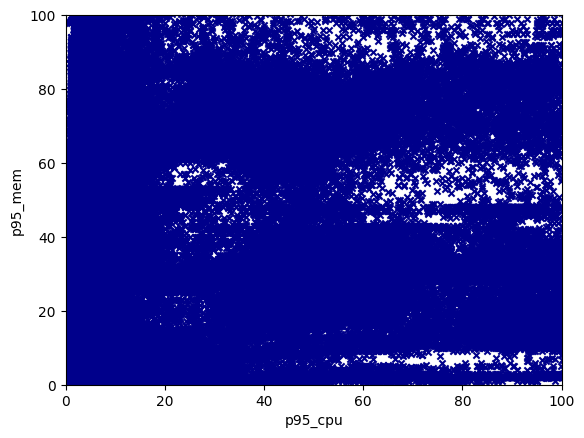

In [54]:
ax1 = df_result.plot.scatter(x='p95_cpu', y='p95_mem', c='DarkBlue', marker="x", xlim=[0, 100], ylim=[0, 100])

In [55]:
df_cost_sum = df_result[['date_key', 'ec2_cost', 'p95_cpu', 'p95_mem']]
df_cost_sum = df_cost_sum[~df_cost_sum['p95_cpu'].isna()]
df_cost_sum = df_cost_sum[~df_cost_sum['p95_mem'].isna()]

df_cost_sum.groupby('date_key').apply(lambda x: np.average(x['p95_cpu'], weights=x['ec2_cost'])).mean()

8.882063345613478

In [56]:
df_cost_sum.groupby('date_key').apply(lambda x: np.average(x['p95_mem'], weights=x['ec2_cost'])).mean()

17.30315082795511

In [57]:
df_utilization_summary = df_result[['resource_type','deployment_name', 'request_cpu', 'request_memory', 'p95_cpu' ,'p95_mem']].groupby(by=['resource_type','deployment_name', 'request_cpu', 'request_memory']).mean().reset_index()
df_utilization_summary.columns = ['resource_type','Deployment Name', 'Request CPU', 'Request Memory', 'Average CPU Utilization (%) at p95 level', 'Average Memory utilization (%) at p95 level']
df_utilization_summary

,resource_type,Deployment Name,Request CPU,Request Memory,Average CPU Utilization (%) at p95 level,Average Memory utilization (%) at p95 level
0,daemonset,aws-node,0.025,67108864.000,15.957,251.534
1,daemonset,aws-node,0.025,268435456.000,26.612,132.022
2,daemonset,aws-node,0.050,67108864.000,11.500,150.512
3,daemonset,aws-node,0.050,134217728.000,13.575,177.376
4,daemonset,dataplane-test-ds,0.030,224395264.000,4.321,19.856
...,...,...,...,...,...,...
1862,replicaset,vpa-generator,0.120,262144000.000,1.299,18.224
1863,statefulset,cloudwatch-logexport,0.220,786432000.000,10.137,77.744
1864,statefulset,cloudwatch-logexport,0.240,943718400.000,4.396,86.800
1865,statefulset,dns-propagation-test,0.100,67108864.000,1.284,2.565


In [58]:
# We want to aggregate daily ec2_cost and saving_opportunity by sum. In order to execute this aggregation,
# 1. Select 'date_key', 'k8s_namespace', 'deployment_name', 'ec2_cost', 'saving_opportunity' columns
# 2. Group by 'date_key', 'k8s_namespace', 'deployment_name' with sum aggregation at deployment level.
# 3. Reset the index

df_dailysaving_by_name = df_result[['date_key',  'resource_type', 'deployment_name', 'ec2_cost', 'saving_opportunity']].groupby(by=['date_key',  'resource_type','deployment_name']).sum().sort_values(by=['date_key','resource_type', 'deployment_name']).reset_index()
df_dailysaving_by_name['yearly_saving'] = df_dailysaving_by_name.apply(lambda x: x['saving_opportunity'] * 365.0, axis=1)
df_dailysaving_by_name.columns = ['Date',  'Resource type', 'Name', 'Daily EC2 cost', 'Daily cost saving opportunity (USD)', 'Yearly saving opportunity estimate (USD, daily saving opportunity * 365)']
df_dailysaving_by_name

,Date,Resource type,Name,Daily EC2 cost,Daily cost saving opportunity (USD),"Yearly saving opportunity estimate (USD, daily saving opportunity * 365)"
0,20250801,daemonset,aws-node,596.982,144.325,52678.673
1,20250801,daemonset,dataplane-test-ds,2683.146,1174.607,428731.638
2,20250801,daemonset,ebs-csi-node,7017.762,3506.496,1279871.008
3,20250801,daemonset,ebs-csi-node-small,0.005,0.002,0.829
4,20250801,daemonset,efs-csi-node,2386.491,1055.086,385106.309
...,...,...,...,...,...,...
4540,20250831,replicaset,vertical-pod-autoscaler-recommender,138.299,58.957,21519.404
4541,20250831,replicaset,vertical-pod-autoscaler-updater,144.129,59.046,21551.851
4542,20250831,replicaset,vpa-generator,0.024,0.011,4.142
4543,20250831,statefulset,cloudwatch-logexport,207.879,81.912,29897.698


In [59]:
df_daily_sum = df_dailysaving_by_name[['Date', 'Daily EC2 cost', 'Daily cost saving opportunity (USD)']].groupby(by='Date').sum().reset_index()
df_daily_sum[['Daily EC2 cost', 'Daily cost saving opportunity (USD)']].mean()

Daily EC2 cost                        25488.238
Daily cost saving opportunity (USD)   11202.931
dtype: float64

In [60]:
df_dailysaving_total_by_namespace = df_result[['date_key',  'ec2_cost', 'saving_opportunity']].groupby(by=['date_key', ]).sum().reset_index()
df_dailysaving_total_by_namespace.columns = ['Date',  'Total daily EC2 cost (USD)', 'Total daily cost saving opportunity (USD)']
df_dailysaving_total_by_namespace

,Date,Total daily EC2 cost (USD),Total daily cost saving opportunity (USD)
0,20250801,25796.802,11377.221
1,20250802,25117.349,11138.075
2,20250803,24976.699,11099.021
3,20250804,25670.120,11270.681
4,20250805,25530.010,11245.708
5,20250806,25594.324,11268.411
6,20250807,25586.715,11258.360
7,20250808,25627.982,11271.974
8,20250809,25064.572,11073.060
9,20250810,24983.466,11063.170


## Export data

In [61]:
# Export dataframe to csv files
df_utilization_summary.to_csv('./hce-costanalysis-utilization-summary-aug01_aug31_all_env.csv', index=False)
df_dailysaving_by_name.to_csv('./hce-costanalysis-cost-saving-aug01_aug31_all_env.csv', index=False)
df_dailysaving_total_by_namespace.to_csv('./hce-costanalysis-total-saving-namespace-aug01_aug31_all_env.csv', index=False)

In [62]:
withcost_hce[withcost_hce['deployment_name'] == 'ebs-csi-controller']

,date_key,scope,falcon_instance,functional_domain,environment_type,allocated_service,k8s_cluster,k8s_namespace,pod_group,ec2_cost,resource_type,resource_name,deployment_name,p99_cpu,p95_cpu,p99_mem,p95_mem,request_cpu,request_memory,saving_opportunity
67,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-processing1,kube-system,ebs-csi-controller-6458b8d75d,0.051,replicaset,ebs-csi-controller-6458b8d75d,ebs-csi-controller,14.000,12.000,73.457,71.675,0.077,217673496.000,0.017
211,20250801,aws.aws-dev2-uswest2.apiq,aws-dev2-uswest2,apiq,dev,sam,sam-restricted1,kube-system,ebs-csi-controller-6cbcd77845,0.059,replicaset,ebs-csi-controller-6cbcd77845,ebs-csi-controller,10.383,8.000,53.000,49.525,0.077,254410174.000,0.023
236,20250801,aws.aws-dev2-uswest2.ast,aws-dev2-uswest2,ast,dev,sam,sam-processing1,kube-system,ebs-csi-controller-f6b67479b,0.048,replicaset,ebs-csi-controller-f6b67479b,ebs-csi-controller,13.069,11.170,65.553,63.013,0.077,203695174.000,0.016
291,20250801,aws.aws-dev2-uswest2.cdp1,aws-dev2-uswest2,cdp1,dev,sam,sam-processing1,kube-system,ebs-csi-controller-55d8895db,0.049,replicaset,ebs-csi-controller-55d8895db,ebs-csi-controller,8.955,8.571,62.899,62.176,0.077,177703736.000,0.018
319,20250801,aws.aws-dev2-uswest2.controltelemetry,aws-dev2-uswest2,controltelemetry,dev,sam,sam-processing1,kube-system,ebs-csi-controller-5d9ddf77d6,0.048,replicaset,ebs-csi-controller-5d9ddf77d6,ebs-csi-controller,6.880,6.375,60.741,59.829,0.077,190382486.000,0.020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
868687,20250831,aws.test1-uswest2.security,test1-uswest2,security,test,sam,sam-mgmt-truth1,kube-system,ebs-csi-controller-78cf455c7b,0.051,replicaset,ebs-csi-controller-78cf455c7b,ebs-csi-controller,9.000,8.000,56.841,56.000,0.077,190382486.000,0.020
868721,20250831,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing1,kube-system,ebs-csi-controller-68d9bc5754,0.049,replicaset,ebs-csi-controller-68d9bc5754,ebs-csi-controller,8.989,8.681,69.976,69.390,0.077,203695174.000,0.019
868758,20250831,aws.test1-uswest2.tableau,test1-uswest2,tableau,test,sam,sam-processing2,kube-system,ebs-csi-controller-6bbd9cdb89,0.048,replicaset,ebs-csi-controller-6bbd9cdb89,ebs-csi-controller,7.000,6.828,56.948,56.394,0.077,190382486.000,0.019
868779,20250831,aws.test1-uswest2.unified-engagement,test1-uswest2,unified-engagement,test,sam,sam-processing1,kube-system,ebs-csi-controller-6b6fb4b4b6,0.049,replicaset,ebs-csi-controller-6b6fb4b4b6,ebs-csi-controller,11.000,10.000,82.769,81.675,0.077,190382486.000,0.018


In [63]:
only_ebscsicontroller= withcost_hce[withcost_hce['deployment_name'] == 'ebs-csi-controller'][['date_key','deployment_name', 'ec2_cost']].groupby(by=['date_key', 'deployment_name']).sum()

In [64]:
only_ebscsicontroller.to_csv('ebs-csi-controller_daily_aug01_aug31_all_env.csv')